## Where Do People Drink The Most Beer, Wine And Spirits?

<img src="https://s1.qwant.com/thumbr/0x0/3/f/a2d61eb9aa851a55e62456389bde7986e358da62a08b5c5ac98aaa851447dc/alcoholconsumption.gif?u=http%3A%2F%2F4.bp.blogspot.com%2F-0u5Sk_omAEE%2FTV3XZtyPQ1I%2FAAAAAAAAArc%2FyVlSiUp6aTU%2Fs1600%2Falcoholconsumption.gif&q=0&b=1&p=0&a=1">

The dataset for this analysis is from this post in [FiveThirtyEight](https://fivethirtyeight.com/features/dear-mona-followup-where-do-people-drink-the-most-beer-wine-and-spirits/)

Data: https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv

In [6]:
import pandas as pd


alc = pd.read_csv("https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv")
alc.head()

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
0,Afghanistan,0,0,0,0.0
1,Albania,89,132,54,4.9
2,Algeria,25,0,14,0.7
3,Andorra,245,138,312,12.4
4,Angola,217,57,45,5.9


## Problem 1
Convert the following data into tidy format with the headers `country`, `drink` and `servings`. Drop the column `total_litres_of_pure_alcohol`

In [7]:
# Drop the "total_litres_of_pure_alcohol" column
alc_adjusted = alc.drop(columns=['total_litres_of_pure_alcohol'])

# Adjusting to change df to tidy format with headers "country", "drink", and "servings"
tidy_alc = alc_adjusted.melt(
    id_vars="country",
    var_name="drink",
    value_name="servings"
)
tidy_alc


,country,drink,servings
0,Afghanistan,beer_servings,0
1,Albania,beer_servings,89
2,Algeria,beer_servings,25
3,Andorra,beer_servings,245
4,Angola,beer_servings,217
...,...,...,...
574,Venezuela,wine_servings,3
575,Vietnam,wine_servings,1
576,Yemen,wine_servings,0
577,Zambia,wine_servings,4


## Problem 2
Remove `"_servings"` from the data in the tidy dataframe in Problem 1. Who drinks the most beer, wine and spirits? Create three categorical plots of your choice to illustrate the top 10 countries that drink the most wine, beer or spirits.

In [8]:
# Removing "_servings" from the tidy dataframe
tidy_alc['drink'] = tidy_alc['drink'].str.replace('_servings', '')
tidy_alc

,country,drink,servings
0,Afghanistan,beer,0
1,Albania,beer,89
2,Algeria,beer,25
3,Andorra,beer,245
4,Angola,beer,217
...,...,...,...
574,Venezuela,wine,3
575,Vietnam,wine,1
576,Yemen,wine,0
577,Zambia,wine,4


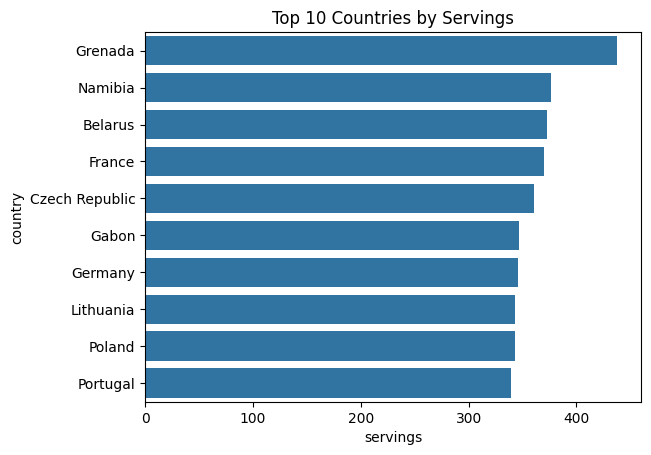

In [16]:
# 1. Bar Plot (Top Countries by servings)

import seaborn as sns
import matplotlib.pyplot as plt

top = tidy_alc.sort_values(by='servings', ascending=False).head(10)

plt.figure()
sns.barplot(data=top, x='servings', y='country')
plt.title('Top 10 Countries by Servings')
plt.show()

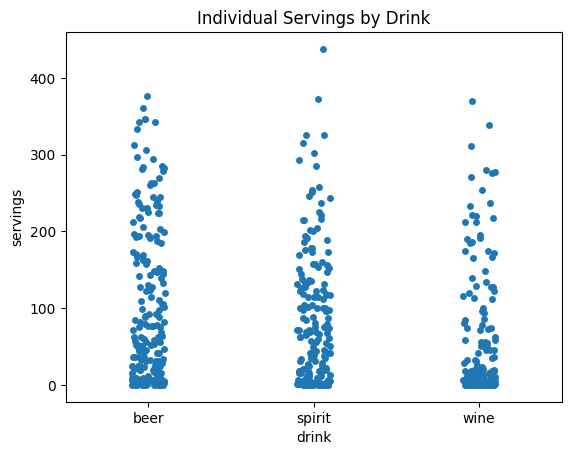

In [19]:
# 2. Strip Plot
plt.figure()
sns.stripplot(data=tidy_alc, x='drink', y='servings', jitter=True)
plt.title('Individual Servings by Drink')
plt.show()

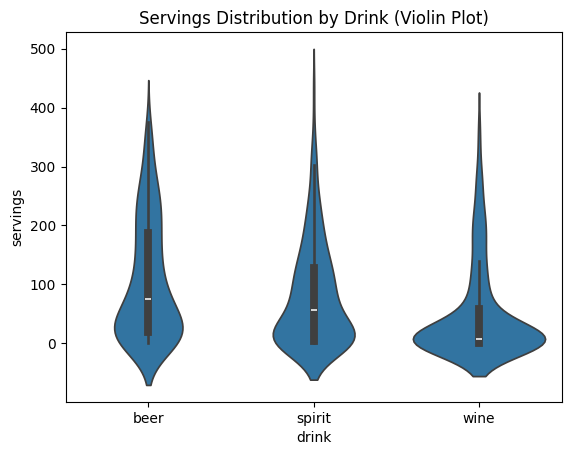

In [18]:
# 3. Violin Plot
plt.figure()
sns.violinplot(data=tidy_alc, x='drink', y='servings')
plt.title('Servings Distribution by Drink (Violin Plot)')
plt.show()

## Problem 3
Create a wide dataframe using `pivot_table` with the tidy dataframe from Problem 2

In [20]:
pd.pivot_table(tidy_alc, values='servings',
                    index=['drink'],
                    columns='country',
                    aggfunc='min'
               )

country,Afghanistan,Albania,Algeria,Andorra,Angola,Antigua & Barbuda,Argentina,Armenia,Australia,Austria,...,United Arab Emirates,United Kingdom,Uruguay,Uzbekistan,Vanuatu,Venezuela,Vietnam,Yemen,Zambia,Zimbabwe
drink,,,,,,,,,,,,,,,,,,,,,
beer,0,89,25,245,217,102,193,21,261,279,...,16,219,115,25,21,333,111,6,32,64
spirit,0,132,0,138,57,128,25,179,72,75,...,135,126,35,101,18,100,2,0,19,18
wine,0,54,14,312,45,45,221,11,212,191,...,5,195,220,8,11,3,1,0,4,4
